# Gradient Boosting Regressor (GBR)

**Reduced feature set (feature extraction using PCA)**

Author: Pete King

Here we introduce a reduced feature set produced using Principal Component Analysis (PCA).  The reduced feature set consists of only 11 features, compared to the original 59, but still captures roughly 85 percent of the variance in the original data.  Ideally, in discarding 15 percent of the variance, we are discarding most of the noise in the data, even though we may also be losing some of the signal.  Overall this should improve the model's ability to fit to the data while avoiding overfitting to noise.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import plot_tree

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
PCA_TRAIN_DATA_FILE = DATA_FOLDER + 'train_pca_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
PCA_VAL_DATA_FILE = DATA_FOLDER + 'val_pca_data.csv'
TICKER = 'SPY'

## I. Import data

We have already split our data into training and validation sets.  We reserve the held-out validation set (val_df) to plot predictions for comparisons against other models, but we further divide the training set into cross-validation folds to take advantage of scikit-learn's [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) function.  This gives us an easy way to apply scikit-learn's standard cross-validation (CV) methods for hyperparameter optimization while preserving chronological order between training and validation subsets within CV folds.

In [2]:
# Combine PCA data with base data. From base data, select only historical 
# volatility and future volatility target.
train_df = dp.make_pca_df(TRAIN_DATA_FILE, PCA_TRAIN_DATA_FILE, TICKER)
val_df = dp.make_pca_df(VAL_DATA_FILE, PCA_VAL_DATA_FILE, TICKER)
train_df

,SPY_ret,SPY_h-vol,SPY_f-vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_macro-5,PCA_indicies-1,PCA_indicies-2,PCA_indicies-3,PCA_indicies-4
date,,,,,,,,,,,,,,
2015-10-22,0.016753,0.007990,0.008038,-0.060385,-0.049302,-0.045180,-0.042780,-0.051164,-0.030192,-0.027020,-0.035612,-0.031673,0.003920,-0.004416
2015-10-23,0.010902,0.008700,0.007682,-0.028761,-0.019623,-0.042593,-0.040932,-0.026452,-0.008330,-0.036960,-0.000326,-0.024071,-0.030029,-0.043408
2015-10-26,-0.002461,0.008729,0.007669,-0.038998,-0.035716,-0.048401,-0.050450,-0.037413,-0.043599,-0.024643,0.013070,-0.043886,-0.037661,-0.007188
2015-10-27,-0.001934,0.008519,0.007657,0.011014,0.006914,0.076367,0.080811,0.070985,-0.022329,-0.023923,-0.006781,-0.033949,-0.052711,-0.068107
2015-10-28,0.011310,0.009114,0.007253,-0.069678,-0.046203,-0.056724,-0.043523,-0.030986,0.005244,0.009962,0.023684,0.088783,0.087957,0.062373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25,-0.000224,0.007469,0.012897,-0.143119,-0.147170,-0.158972,-0.164089,-0.165783,-0.205792,-0.082340,-0.054542,0.063587,0.081313,0.008595
2022-11-28,-0.016086,0.008508,0.012706,-0.009138,0.052201,0.074293,0.078177,0.077974,-0.028327,-0.015203,-0.033317,-0.047889,-0.073258,-0.059011
2022-11-29,-0.001719,0.008086,0.013284,-0.153767,-0.197632,-0.167729,-0.112797,-0.078021,-0.137523,-0.152878,-0.046367,-0.021137,0.021585,0.059925


In [3]:
val_df

,SPY_ret,SPY_h-vol,SPY_f-vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_macro-5,PCA_indicies-1,PCA_indicies-2,PCA_indicies-3,PCA_indicies-4
date,,,,,,,,,,,,,,
2023-01-03,-0.004219,0.010242,0.011025,0.453110,0.416835,0.381414,0.326702,0.354621,0.360311,0.337204,0.291585,0.291259,0.358576,0.305696
2023-01-04,0.007691,0.010177,0.011143,0.317675,0.311223,0.310984,0.294959,0.261770,0.240383,0.213406,0.250842,0.217873,0.185065,0.198466
2023-01-05,-0.011479,0.010796,0.010940,0.206405,0.258067,0.235417,0.230884,0.254676,0.296916,0.303690,0.282478,0.260471,0.297770,0.289716
2023-01-06,0.022673,0.012081,0.010161,0.382678,0.367219,0.349151,0.388915,0.363785,0.384096,0.367638,0.377479,0.353326,0.390000,0.430783
2023-01-09,-0.000567,0.011195,0.010439,0.401736,0.431695,0.521250,0.756041,0.699941,0.724333,0.684553,0.786744,0.791241,0.633941,0.517984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,-0.002387,0.009243,0.008510,0.329960,0.387138,0.362461,0.330073,0.330884,0.296511,0.139929,0.181070,0.182610,0.201420,0.195621
2024-08-27,0.001372,0.007682,0.008549,0.152327,0.150704,0.200752,0.162793,0.159418,0.108765,0.115386,0.132175,0.131496,0.134801,0.185632
2024-08-28,-0.005822,0.007836,0.008460,0.137624,0.144313,0.192165,0.154747,0.155202,0.120963,0.152945,0.166141,0.151012,0.094235,0.129049


In [4]:
# Separate features from labels
data_cols, _ = dp.get_X_y_cols(train_df, returns=True)
label_col = [TICKER + '_f-vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=21
)

## II. Define model, fit to data, and evaluate performance

Here we select several hyperparameters that we chose using a grid search method.  The 'learning rate' parameter shrinks the contribution of each tree, while 'n_estimators' represents the number of boosting stages to perform.  Decreasing the learning rate while increasing the number of estimators is like taking a larger sample and averaging results.  With 'max_features', we limit the number of features allowed at each boosting stage, and with 'max_depth', we limit the depth of the decision tree at each stage.

Max depth is perhaps the most important hyperparameter, and we keep it low to avoid overfitting to the training data.

In [5]:
# Define model, metrics, and Grid Search for hyperparameter tuning
reg = GradientBoostingRegressor(
    loss='squared_error',
    learning_rate=0.1,
    max_features='sqrt',
    max_depth=2,
    n_estimators=200
)

In [6]:
reg.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

### Visualize performance; Check evaluation metrics

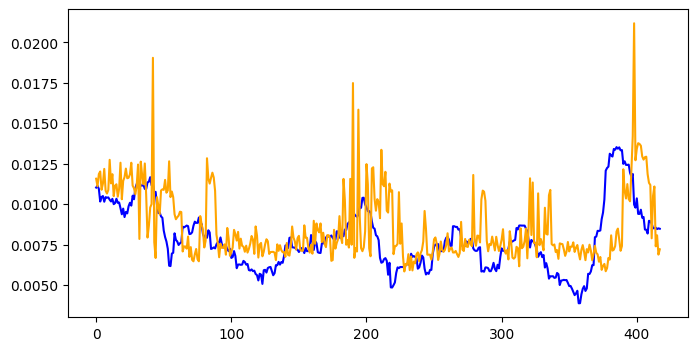

In [7]:
# Use the best estimator to make predictions on the validation set
# best = reg.best_estimator_
preds = reg.predict(X_val)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')

In [8]:
print(f'MAE: {mean_absolute_error(y_val, preds)}')
print(f'R2: {r2_score(y_val, preds)}')

MAE: 0.0017930220218407692
R2: -0.5424312753794154


It is not clear how well the PCA features aid the model in making accurate predictions.  Clearly there are times when the additional features seem to throw the model off, where it makes extreme outlier predictions.  Overall, the dimensionality reduction does not appear to be especially helpful for the GBR model, compared to the case where we introduce all features to the model.  Even though MAE is lower for the PCA-featured model, and its estimates are generally less biased, the strange outlier spiking behavior makes the PCA-based model less reliable than the full-featured model.

## III. Inspect model

In part we chose a decision tree based model because the implementations in scikit-learn give us an easy way to understand which features are most important in its decision-making process.  Let's take a look and see which features have been most important for our GBR.

In [9]:
feature_importances = list(
    zip(reg.feature_names_in_, reg.feature_importances_)
)
for feature, coef in sorted(feature_importances, key=lambda i: -i[1]):
    print(f'{feature}: {coef:2.3f}')

SPY_h-vol: 0.536
SPY_ret: 0.181
PCA_macro-1: 0.046
PCA_indicies-1: 0.041
PCA_indicies-4: 0.032
PCA_macro-5: 0.030
PCA_macro-2: 0.029
PCA_macro-4: 0.028
PCA_indicies-3: 0.023
PCA_vol-1: 0.016
PCA_macro-3: 0.013
PCA_vol-2: 0.012
PCA_indicies-2: 0.011


Near-term historical volatility for is by far the most important feature in the GBR's decision-making process.  The low feature importance attributed to the PCA-derived factors, combined with the instances of "spiky" outlier predictions in the PCA-based model, leads me to believe that the additional features ultimately lead the model astray more than they help remove bias or improve prediction accuracy.